# Lab 5: Decision Trees and Random Forests

A- Decision Trees:

* Decision Trees are a type of supervised machine learning algorithm used for both classification and regression tasks.
* They work by recursively splitting the data into subsets based on the most significant features.
* At each node of the tree, a decision is made by evaluating a feature's value.
The goal is to create a tree structure that best separates or predicts the target variable.
* Decision Trees can be prone to overfitting, but they are interpretable and can serve as the basis for more advanced ensemble methods.

B- Random Forests:

* Random Forests are an ensemble learning method based on Decision Trees.
They create multiple Decision Trees during training, each with a random subset of the data and features.
* When making predictions, the results from multiple trees are combined (e.g., voting for classification or averaging for regression).
* Random Forests improve the robustness and generalization of the model and reduce the risk of overfitting.
* They are widely used for classification and regression tasks and are known for their accuracy and versatility.

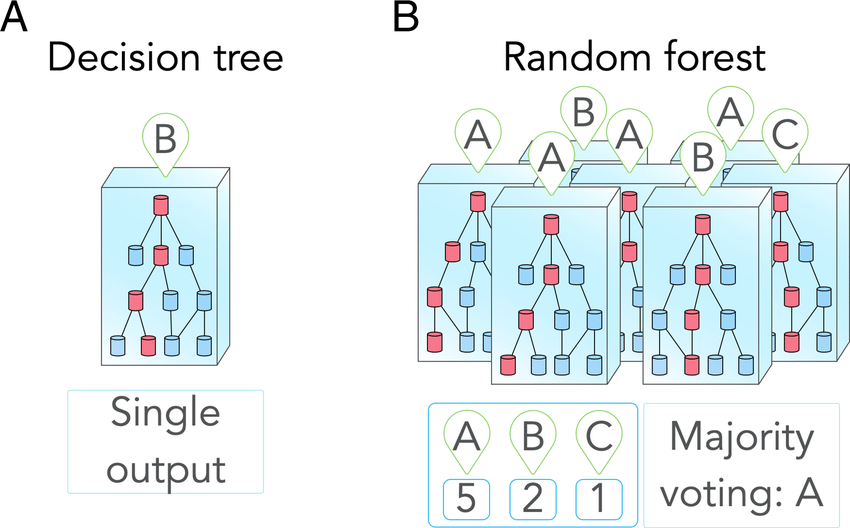

In [1]:
# import the libraries we need
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

The dataset I will be using: [link](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/overview)

Data Description: [link](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data)

In [2]:
# Load the House Prices dataset and view it
df = pd.read_csv('train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


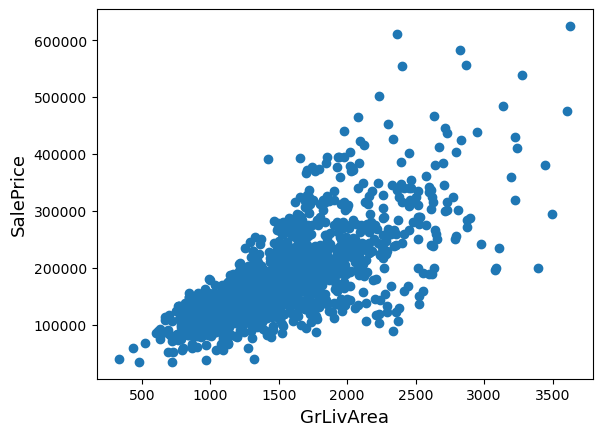

In [3]:
# Delete the outliers -> df['GrLivArea']>4000
df_sample = df.drop(df[df['GrLivArea']>4000].index)

# plot SalePrice Vs. GrLivArea
fig, ax = plt.subplots()
ax.scatter(df_sample['GrLivArea'], df_sample['SalePrice'])
plt.ylabel('SalePrice', fontsize=13)
plt.xlabel('GrLivArea', fontsize=13)
plt.show()

In [4]:
# filter the dataset based on the following columns
columns_to_use = ['LotArea', 'YrSold', 'GarageArea', 'GarageYrBlt',
                  'GrLivArea', 'OverallQual', 'MasVnrArea', 'YearBuilt', 'SalePrice']

# save the new dataset into df_sample
df_sample = df.loc[:, columns_to_use]

In [5]:
df_sample

,LotArea,YrSold,GarageArea,GarageYrBlt,GrLivArea,OverallQual,MasVnrArea,YearBuilt,SalePrice
0,8450,2008,548,2003.0,1710,7,196.0,2003,208500
1,9600,2007,460,1976.0,1262,6,0.0,1976,181500
2,11250,2008,608,2001.0,1786,7,162.0,2001,223500
3,9550,2006,642,1998.0,1717,7,0.0,1915,140000
4,14260,2008,836,2000.0,2198,8,350.0,2000,250000
...,...,...,...,...,...,...,...,...,...
1455,7917,2007,460,1999.0,1647,6,0.0,1999,175000
1456,13175,2010,500,1978.0,2073,6,119.0,1978,210000
1457,9042,2010,252,1941.0,2340,7,0.0,1941,266500
1458,9717,2010,240,1950.0,1078,5,0.0,1950,142125


In [6]:
# look into the number of nulls we have
nulls = df_sample.isnull().sum()
nulls

LotArea         0
YrSold          0
GarageArea      0
GarageYrBlt    81
GrLivArea       0
OverallQual     0
MasVnrArea      8
YearBuilt       0
SalePrice       0
dtype: int64

In [7]:
# fillna with mean for: GarageYrBlt, MasVnrArea
df_sample.fillna(df_sample.mean(), inplace=True)

In [8]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   LotArea      1460 non-null   int64  
 1   YrSold       1460 non-null   int64  
 2   GarageArea   1460 non-null   int64  
 3   GarageYrBlt  1460 non-null   float64
 4   GrLivArea    1460 non-null   int64  
 5   OverallQual  1460 non-null   int64  
 6   MasVnrArea   1460 non-null   float64
 7   YearBuilt    1460 non-null   int64  
 8   SalePrice    1460 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 102.8 KB


In [9]:
# create the X and Y where Y is our target column 'SalePrice' and X is everything else.
X = df_sample.drop(['SalePrice'], axis=1)
y = df_sample['SalePrice']

#Split the dataset into training and validation subsets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


In [10]:
from sklearn.tree import DecisionTreeRegressor

# Create a Decision Tree model
decision_tree = DecisionTreeRegressor(random_state=42)

# Fit the model to the training data
decision_tree.fit(X_train, y_train)

# How may levels are there?
decision_tree.tree_.max_depth

21

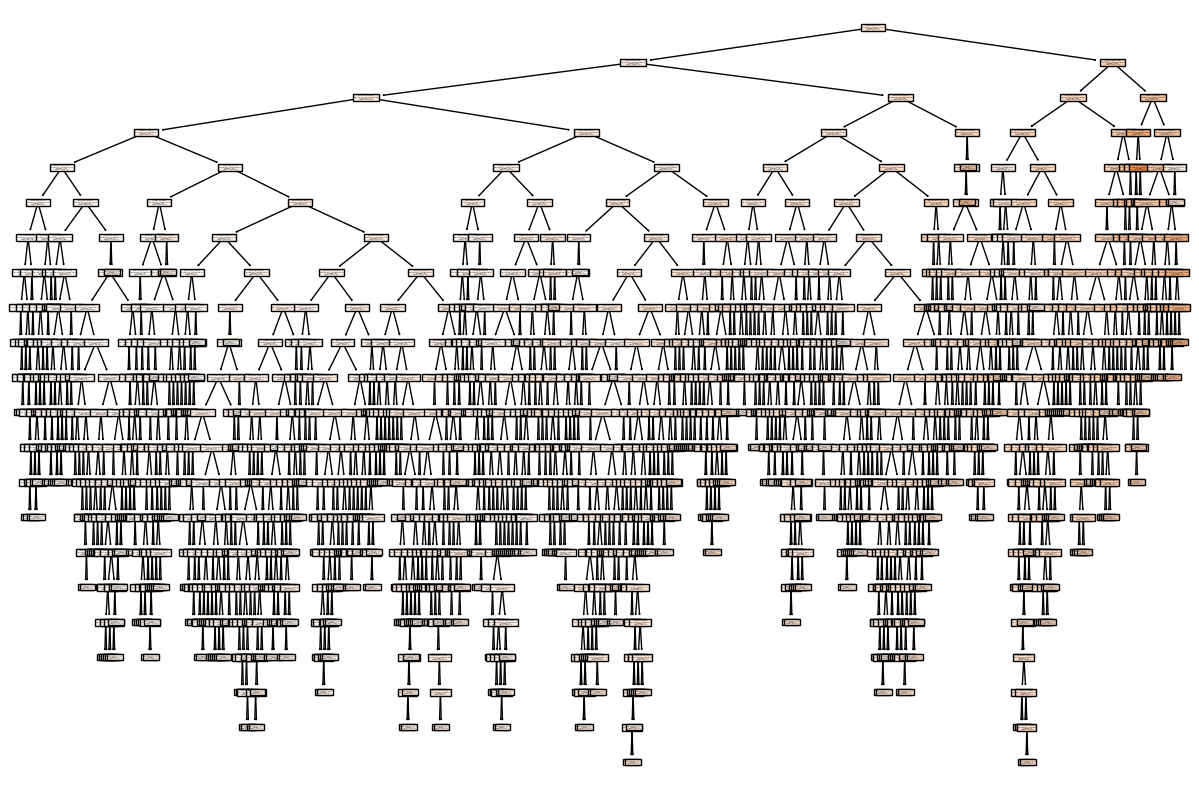

In [11]:
from sklearn.tree import plot_tree

# plot the tree
plt.figure(figsize=(15, 10))
plot_tree(decision_tree, filled=True, feature_names=list(X.columns))
plt.show()


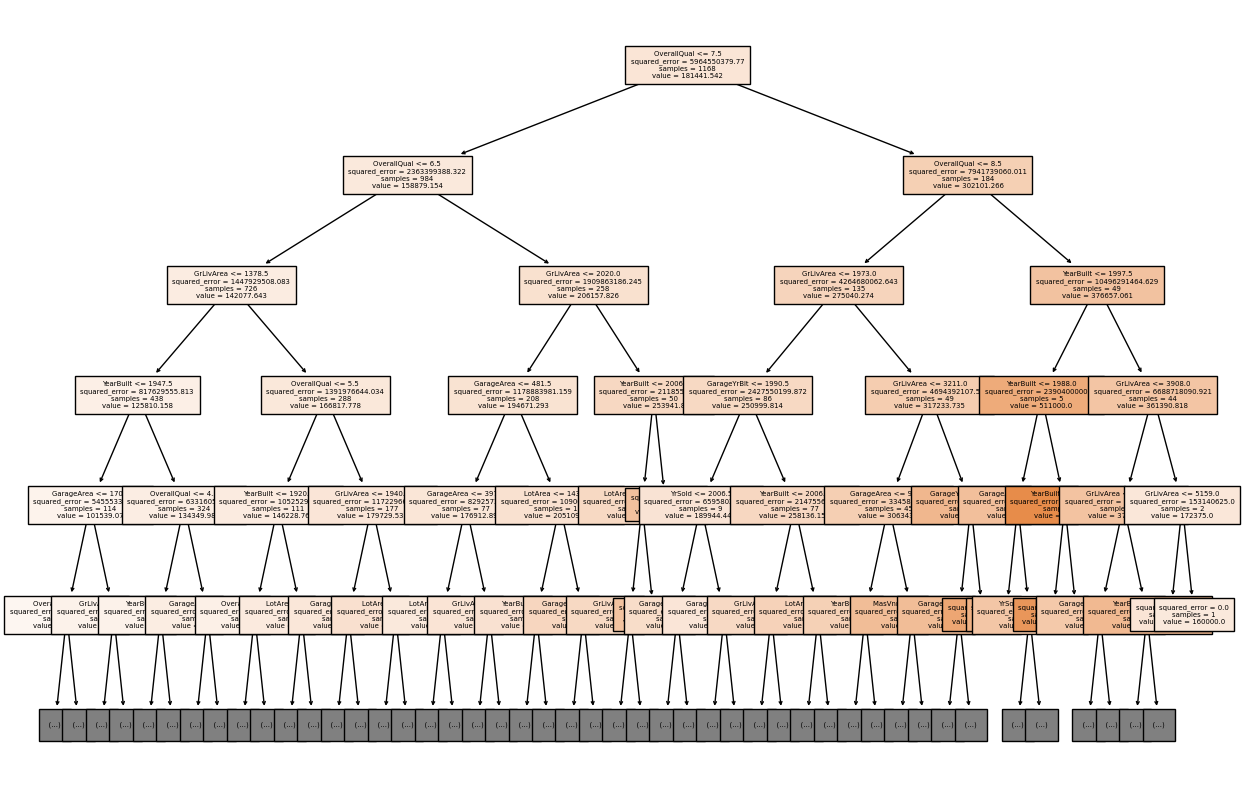

In [12]:
# change max_depth to see only the first few features and plot the tree again
plt.figure(figsize=(15, 10))
plot_tree(decision_tree, filled=True, feature_names=list(X.columns), max_depth=5, fontsize=5)
plt.show()


In [13]:
from sklearn.ensemble import RandomForestRegressor

# Create a Random Forest model with n_estimators=100 and random_state=42
random_forest = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit the model to the training data
random_forest.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [14]:
# Evaluate the Decision Tree performance

DT_train_acc = decision_tree.score(X_train, y_train)
DT_val_acc = decision_tree.score(X_val, y_val)

# Evaluate the Random Forest performance
RF_train_acc = random_forest.score(X_train, y_train)
RF_val_acc = random_forest.score(X_val, y_val)

# Print the results
print("Decision Tree Training Accuracy:", DT_train_acc)
print("Decision Tree Validation Accuracy:", DT_val_acc)
print("Random Forest Training Accuracy:", RF_train_acc)
print("Random Forest Validation Accuracy:", RF_val_acc)


Decision Tree Training Accuracy: 0.9999916899786337
Decision Tree Validation Accuracy: 0.7696613346151218
Random Forest Training Accuracy: 0.9721992419511185
Random Forest Validation Accuracy: 0.8688351985247227


Are we under- or overfitting? We need to pre-prune the decision tree model

In [15]:
# Create a Decision Tree model
decision_tree = DecisionTreeRegressor(random_state=42, max_depth=7)

# Fit the model to the training data
decision_tree.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=7, random_state=42)

In [16]:
# Evaluate the Decision Tree performance

DT_train_acc = decision_tree.score(X_train, y_train)
DT_val_acc = decision_tree.score(X_val, y_val)

# Evaluate the Random Forest performance
RF_train_acc = random_forest.score(X_train, y_train)
RF_val_acc = random_forest.score(X_val, y_val)

# Print the results
print("Decision Tree Training Accuracy:", DT_train_acc)
print("Decision Tree Validation Accuracy:", DT_val_acc)
print("Random Forest Training Accuracy:", RF_train_acc)
print("Random Forest Validation Accuracy:", RF_val_acc)

Decision Tree Training Accuracy: 0.9167679893330712
Decision Tree Validation Accuracy: 0.8231697577317484
Random Forest Training Accuracy: 0.9721992419511185
Random Forest Validation Accuracy: 0.8688351985247227


References

* https://www.google.com/search?q=decision+tree+algorithm&sca_esv=572530057&biw=1536&bih=707&tbm=vid&sxsrf=AM9HkKn2OLtD25h_k9-65mPCVRoOifFNZA%3A1697030869036&ei=1aImZZLpAeyF0PEP3fitgAI&oq=dec&gs_lp=Eg1nd3Mtd2l6LXZpZGVvIgNkZWMqAggAMggQABiKBRiRAjIHEAAYigUYQzIIEAAYigUYkQIyBxAAGIoFGEMyBRAAGIAEMgUQABiABDIFEAAYgAQyBRAAGIAEMggQABiABBixAzIFEAAYgARIhxRQhgZY4AlwAXgAkAEAmAGJAaAB7AOqAQMzLjK4AQPIAQD4AQHCAgQQIxgnwgIGEAAYFhgewgIIEAAYigUYhgPCAgsQABiKBRixAxiDAcICCxAAGIAEGLEDGIMBiAYB&sclient=gws-wiz-video#fpstate=ive&vld=cid:3863e517,vid:_L39rN6gz7Y,st:0


* https://www.youtube.com/watch?v=_L39rN6gz7Y&ab_channel=StatQuestwithJoshStarmer
* https://www.kaggle.com/code/vincentbrunner/ml-from-scratch-decision-trees